# LoRa MIMO DSP Chain — Step-by-Step Walkthrough

NT=1, NR=4 MRC path. Each cell runs one stage and shows intermediate state.

**Stages:**
1. Modulation
2. Channel (Rayleigh + AWGN)
3. Energy detector
4. Preamble correlator → channel estimates
5a. Phase extraction
5b. Phase correction
5c. Combining weights
6. MRC combine
8. ΣΔ remodulator + LPF
9. Demodulation

In [179]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('../..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

from sim.models.lora     import upchirp, modulate, demodulate
from sim.models.channel  import rayleigh_coefficients, apply_channel
from sim.models.stages   import energy_detector, CorrelatorBank
from sim.models.receiver import compute_weights, mrc_combine
from sim.models.converter import SigmaDeltaRemodulator

rng = np.random.default_rng(41)
np.random.seed(41)  # models use np.random directly

# --- Parameters ---
SF  = 9
M   = 2 ** SF   # 128 chips per symbol
NR  = 4         # receive antennas
SNR_DB = -5.0
N0  = 10 ** (-SNR_DB / 10)
N_PREAMBLE = 8  # preamble symbols

print(f'SF={SF}  M={M}  NR={NR}  SNR={SNR_DB} dB  N0={N0:.4f}')

SF=9  M=512  NR=4  SNR=-5.0 dB  N0=3.1623


## Stage 1 — Modulation
Pick a random symbol `b` and generate the CSS chirp.

Transmitted symbol: b_tx = 340


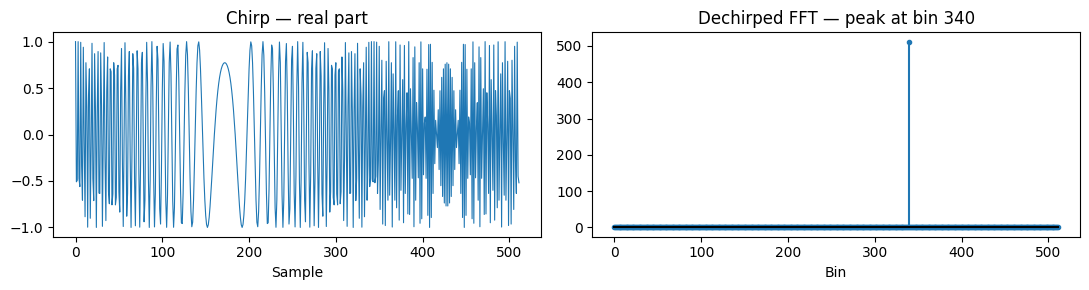

In [180]:
b_tx = int(rng.integers(0, M))
s = modulate(b_tx, M)

print(f'Transmitted symbol: b_tx = {b_tx}')

fig, axes = plt.subplots(1, 2, figsize=(11, 3))

n = np.arange(M)
axes[0].plot(n, s.real, lw=0.8)
axes[0].set_title('Chirp — real part')
axes[0].set_xlabel('Sample')

dechirped_ref = s * np.exp(-1j * np.pi * n**2 / M)
fft_ref = np.abs(np.fft.fft(dechirped_ref))
axes[1].stem(fft_ref, markerfmt='C0.', linefmt='C0-', basefmt='k-')
axes[1].set_title(f'Dechirped FFT — peak at bin {b_tx}')
axes[1].set_xlabel('Bin')

plt.tight_layout()
plt.show()

SF=9  M=512  upsample=8  nfft=181  visible freq bins ≈ 22


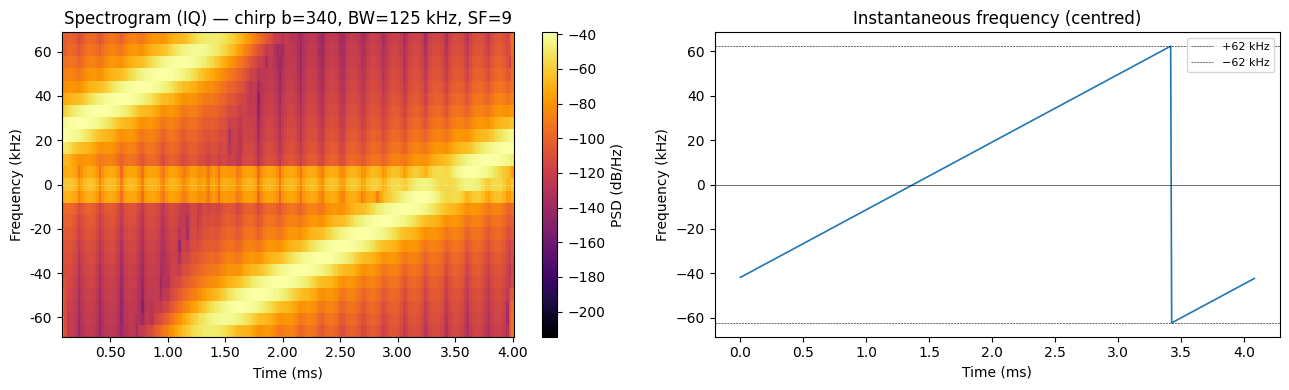

In [181]:

BW = 125e3  # LoRa bandwidth in Hz; chip rate = BW (one sample per chip)
Fs = BW

from scipy.signal import resample_poly as _resample
from scipy.signal import spectrogram  as _spectrogram

ms  = lambda x, _: f'{x*1e3:.2f}'
khz = lambda y, _: f'{y/1e3:.0f}'

def plot_specgram(ax, sig, nfft=None, noverlap=None, fs=Fs, upsample=8, **kwargs):
    """
    Spectrogram for complex IQ, centred at DC.

    The LoRa chirp formula exp(j·π·(2b·n+n²)/M) has instantaneous frequency
    in [0, BW].  Multiplying by exp(-j·π·n) before upsampling shifts it to
    [−BW/2, +BW/2].  The shift MUST happen before resample_poly because the
    polyphase LPF cuts at BW/2 (original Nyquist); any content above that is
    lost if it arrives after upsampling.

    nfft defaults to upsample × √M — the largest window that keeps each
    chirp sweep to ≤1 bin, giving √M visible frequency bins across the BW.
    Visible bins: SF7→11, SF9→22, SF12→64.
    """
    # Centre at DC before upsampling so the polyphase LPF passes everything
    n_orig = np.arange(len(sig))
    sig = sig * np.exp(-1j * np.pi * n_orig)

    if upsample > 1:
        sig_up = _resample(sig.real, upsample, 1) + 1j * _resample(sig.imag, upsample, 1)
        fs_up  = fs * upsample
    else:
        sig_up, fs_up = sig, fs

    if nfft is None:
        nfft = max(16, int(upsample * M ** 0.5))   # M is the global chips-per-symbol

    if noverlap is None:
        noverlap = nfft * 7 // 8

    f, t, Sxx = _spectrogram(
        sig_up, fs=fs_up, nperseg=nfft, noverlap=noverlap,
        return_onesided=False, scaling='density', window='hann'
    )
    f   = np.fft.fftshift(f)
    Sxx = np.fft.fftshift(Sxx, axes=0)
    Sxx_db = 10 * np.log10(np.abs(Sxx) + 1e-30)

    kw = dict(cmap='inferno', shading='auto')
    kw.update(kwargs)
    im = ax.pcolormesh(t, f, Sxx_db, **kw)

    # 10% padding so the ±BW/2 chirp edge doesn't touch the axis boundary
    ax.set_ylim(-fs / 2 * 1.1, fs / 2 * 1.1)
    ax.axhline(0, color='white', lw=0.5, linestyle='--', alpha=0.4)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(ms))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(khz))
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Frequency (kHz)')
    return im

nfft_used = max(16, int(8 * M ** 0.5))
print(f'SF={SF}  M={M}  upsample=8  nfft={nfft_used}  visible freq bins ≈ {nfft_used // 8}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

im = plot_specgram(axes[0], s, fs=Fs)
axes[0].set_title(f'Spectrogram (IQ) — chirp b={b_tx}, BW={BW/1e3:.0f} kHz, SF={SF}')
fig.colorbar(im, ax=axes[0], label='PSD (dB/Hz)')

inst_freq = np.angle(s[1:] * np.conj(s[:-1])) / (2 * np.pi) * Fs
axes[1].plot(np.arange(M - 1) / Fs * 1e3, inst_freq / 1e3, lw=1.2)
axes[1].set_title('Instantaneous frequency (centred)')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Frequency (kHz)')
axes[1].axhline( BW/2e3, color='k', lw=0.4, linestyle='--', label=f'+{BW/2e3:.0f} kHz')
axes[1].axhline(-BW/2e3, color='k', lw=0.4, linestyle='--', label=f'−{BW/2e3:.0f} kHz')
axes[1].axhline(0, color='k', lw=0.4)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


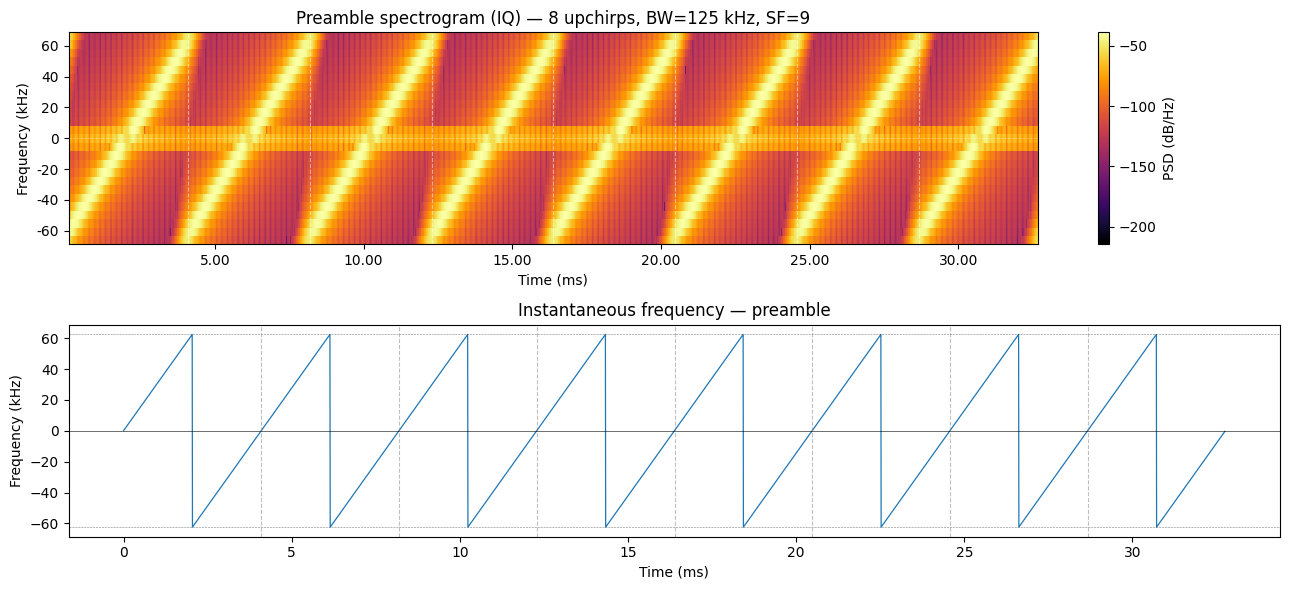

Symbol duration:   4.096 ms
Preamble duration: 32.768 ms


In [182]:

preamble = np.tile(upchirp(M), N_PREAMBLE)  # 8 × M chips

fig, axes = plt.subplots(2, 1, figsize=(13, 6))

im = plot_specgram(axes[0], preamble, fs=Fs)   # auto nfft = upsample × √M
# Mark symbol boundaries
for k in range(1, N_PREAMBLE):
    axes[0].axvline(k * M / Fs, color='white', lw=0.8, linestyle='--', alpha=0.5)
axes[0].set_title(f'Preamble spectrogram (IQ) — {N_PREAMBLE} upchirps, BW={BW/1e3:.0f} kHz, SF={SF}')
fig.colorbar(im, ax=axes[0], label='PSD (dB/Hz)')

t_pre          = np.arange(len(preamble) - 1) / Fs * 1e3
inst_freq_pre  = np.angle(preamble[1:] * np.conj(preamble[:-1])) / (2 * np.pi) * Fs
axes[1].plot(t_pre, inst_freq_pre / 1e3, lw=0.9)
axes[1].set_title('Instantaneous frequency — preamble')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Frequency (kHz)')
axes[1].axhline( BW/2e3, color='k', lw=0.4, linestyle='--', alpha=0.5)
axes[1].axhline(-BW/2e3, color='k', lw=0.4, linestyle='--', alpha=0.5)
axes[1].axhline(0, color='k', lw=0.4)
for k in range(1, N_PREAMBLE):
    axes[1].axvline(k * M / Fs * 1e3, color='grey', lw=0.8, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

symbol_duration_ms = M / Fs * 1e3
print(f'Symbol duration:   {symbol_duration_ms:.3f} ms')
print(f'Preamble duration: {N_PREAMBLE * symbol_duration_ms:.3f} ms')


## Stage 2 — Channel
Generate NR independent Rayleigh fading coefficients and pass the chirp through each.

In [183]:
h_true = rayleigh_coefficients(NR, pll_phase_random=True)
rx_payload = np.stack([apply_channel(s, h_true[j], N0) for j in range(NR)])

print(f'rx_payload shape: {rx_payload.shape}  (NR × M)\n')
print(f'{"Ant":>3}  {"h":>20}  {"|h|":>6}  {"∠h (°)":>9}')
print('-' * 44)
for j, hj in enumerate(h_true):
    print(f'  {j}  {hj:>20.4f}  {abs(hj):>6.4f}  {np.degrees(np.angle(hj)):>+9.1f}°')

rx_payload shape: (4, 512)  (NR × M)

Ant                     h     |h|     ∠h (°)
--------------------------------------------
  0        0.2541+0.3646j  0.4444      +55.1°
  1       -0.7045-0.2241j  0.7392     -162.4°
  2       -0.1691-0.1208j  0.2078     -144.5°
  3        0.2418+0.8255j  0.8602      +73.7°


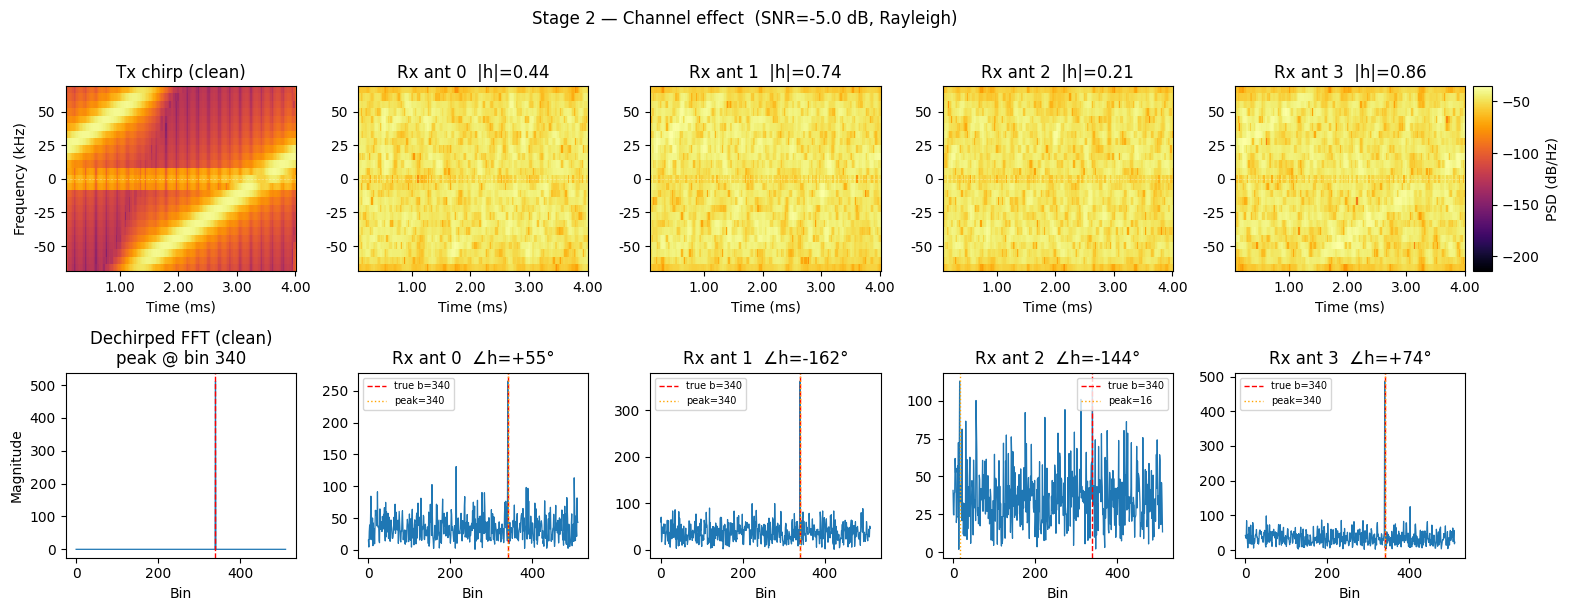

In [184]:

fig, axes = plt.subplots(2, NR + 1, figsize=(15, 6))
n = np.arange(M)

def dechirp_fft(sig):
    return np.abs(np.fft.fft(sig * np.exp(-1j * np.pi * n**2 / M)))

# Row 0: spectrograms — clean chirp then each antenna, shared colour scale
ims = []
ims.append(plot_specgram(axes[0, 0], s, fs=Fs))
axes[0, 0].set_title('Tx chirp (clean)')

for j in range(NR):
    ims.append(plot_specgram(axes[0, j + 1], rx_payload[j], fs=Fs))
    axes[0, j + 1].set_title(f'Rx ant {j}  |h|={abs(h_true[j]):.2f}')
    axes[0, j + 1].set_ylabel('')

# Normalise colour scale across all spectrograms
clims  = [im.get_clim() for im in ims]
vmin_s = min(c[0] for c in clims)
vmax_s = max(c[1] for c in clims)
for im in ims:
    im.set_clim(vmin_s, vmax_s)
# Row 1: dechirped FFT — clean chirp then each noisy antenna
fft_clean = dechirp_fft(s)
axes[1, 0].plot(fft_clean, lw=0.9)
axes[1, 0].axvline(b_tx, color='red', lw=1, linestyle='--')
axes[1, 0].set_title(f'Dechirped FFT (clean)\npeak @ bin {b_tx}')
axes[1, 0].set_ylabel('Magnitude')
axes[1, 0].set_xlabel('Bin')

for j in range(NR):
    fft_rx = dechirp_fft(rx_payload[j])
    peak   = np.argmax(fft_rx)
    axes[1, j + 1].plot(fft_rx, lw=0.9)
    axes[1, j + 1].axvline(b_tx, color='red', lw=1, linestyle='--', label=f'true b={b_tx}')
    axes[1, j + 1].axvline(peak, color='orange', lw=1, linestyle=':', label=f'peak={peak}')
    axes[1, j + 1].set_title(f'Rx ant {j}  ∠h={np.degrees(np.angle(h_true[j])):+.0f}°')
    axes[1, j + 1].legend(fontsize=7)
    axes[1, j + 1].set_xlabel('Bin')

plt.suptitle(f'Stage 2 — Channel effect  (SNR={SNR_DB} dB, Rayleigh)', y=1.01)
plt.tight_layout()
# Add colorbar after tight_layout so axis positions are final
pos = axes[0, -1].get_position()
cax = fig.add_axes([pos.x1 + 0.005, pos.y0, 0.013, pos.height])
fig.colorbar(ims[-1], cax=cax, label='PSD (dB/Hz)')
plt.show()


### Channel estimation from a single pilot chirp
With the transmitted chirp `s` known at the receiver, the least-squares channel estimate per antenna is:

$$\hat{h}_j = \frac{s^H \, r_j}{\|s\|^2} = \frac{1}{M} \sum_n s^*[n] \, r_j[n]$$

This is a matched-filter / correlation operation. With one symbol the estimate is noisy (SNR-limited); Stage 4 averages over 8 preamble symbols to reduce variance.

||s||² = 512.0  (= M = 512)

Ant                h_true       h_hat (1 chirp)   |error|  ∠error (°)
--------------------------------------------------------------------
  0        0.2541+0.3646j        0.3185+0.4087j    0.0781        -3.1°
  1       -0.7045-0.2241j       -0.6654-0.2405j    0.0423        +2.2°
  2       -0.1691-0.1208j       -0.1574-0.1381j    0.0209        +5.7°
  3        0.2418+0.8255j        0.2867+0.9064j    0.0925        -1.2°


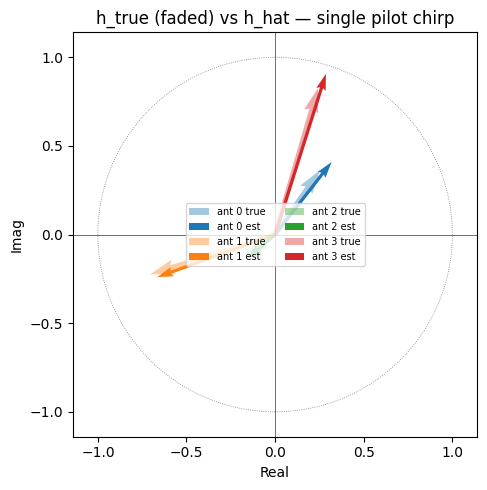

In [185]:
# LS channel estimate: correlate each received antenna with the known pilot chirp
s_norm_sq = np.dot(s.conj(), s).real  # = M (chirp is unit-amplitude)
h_hat_single = np.array([np.dot(s.conj(), rx_payload[j]) / s_norm_sq for j in range(NR)])

print(f'||s||² = {s_norm_sq:.1f}  (= M = {M})\n')
print(f'{"Ant":>3}  {"h_true":>20}  {"h_hat (1 chirp)":>20}  {"|error|":>8}  {"∠error (°)":>10}')
print('-' * 68)
for j in range(NR):
    err = h_hat_single[j] - h_true[j]
    ang_err = np.degrees(np.angle(h_hat_single[j]) - np.angle(h_true[j]))
    print(f'  {j}  {h_true[j]:>20.4f}  {h_hat_single[j]:>20.4f}  {abs(err):>8.4f}  {ang_err:>+10.1f}°')

# IQ plane: true vs estimated using quiver
fig, ax = plt.subplots(figsize=(5, 5))
for j in range(NR):
    # true — dashed style via two overlapping quiver calls
    ax.quiver(0, 0, h_true[j].real, h_true[j].imag,
              angles='xy', scale_units='xy', scale=1,
              color=f'C{j}', alpha=0.4, width=0.012, label=f'ant {j} true')
    ax.quiver(0, 0, h_hat_single[j].real, h_hat_single[j].imag,
              angles='xy', scale_units='xy', scale=1,
              color=f'C{j}', width=0.008, label=f'ant {j} est')

lim = max(np.abs(np.concatenate([h_true, h_hat_single])).max() * 1.2, 0.5)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
circle = plt.Circle((0, 0), 1, color='grey', fill=False, lw=0.6, linestyle=':')
ax.add_patch(circle)
ax.axhline(0, color='k', lw=0.4)
ax.axvline(0, color='k', lw=0.4)
ax.set_aspect('equal')
ax.legend(fontsize=7, ncol=2)
ax.set_title('h_true (faded) vs h_hat — single pilot chirp')
ax.set_xlabel('Real')
ax.set_ylabel('Imag')
plt.tight_layout()
plt.show()

## Stage 3 — Energy Detector
Estimates per-antenna signal energy using 8-bit quantised arithmetic (mirrors RTL).

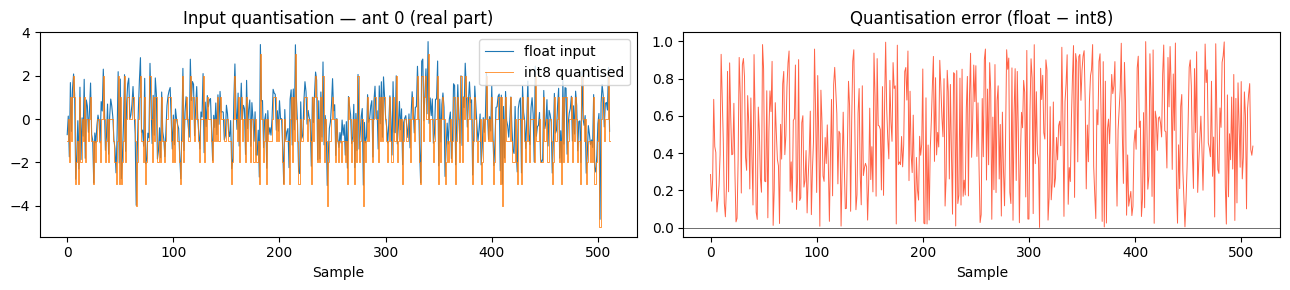

Input range:  [-4.817, 4.106]
int8 range:   [-128, 127]
Max |quant error|: 0.9979


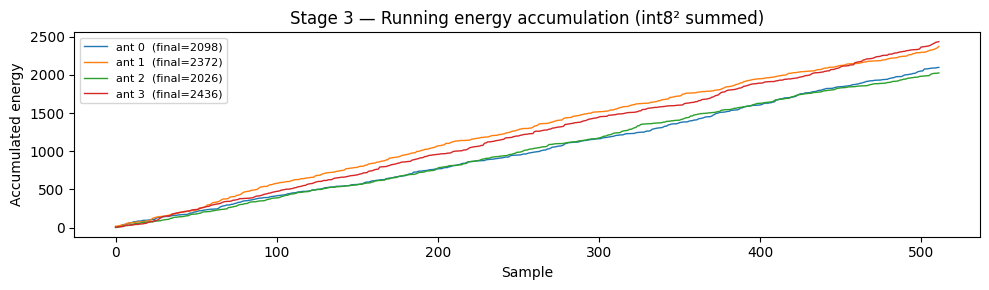

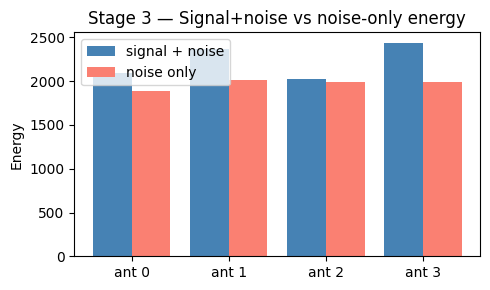

In [186]:
from sim.models.fixed import quantize

# --- Step 1: int8 quantisation of the rx samples (hardware input width) ---
rx_q = quantize(rx_payload.real, 8, signed=True) + 1j * quantize(rx_payload.imag, 8, signed=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 3))
j_show = 0  # show antenna 0
axes[0].plot(rx_payload[j_show].real, lw=0.8, label='float input')
axes[0].step(range(M), rx_q[j_show].real, lw=0.7, alpha=0.8, label='int8 quantised', where='mid')
axes[0].set_title(f'Input quantisation — ant {j_show} (real part)')
axes[0].set_xlabel('Sample')
axes[0].legend()

quant_err = rx_payload[j_show].real - rx_q[j_show].real
axes[1].plot(quant_err, lw=0.7, color='tomato')
axes[1].axhline(0, color='k', lw=0.4)
axes[1].set_title('Quantisation error (float − int8)')
axes[1].set_xlabel('Sample')

plt.tight_layout()
plt.show()
print(f'Input range:  [{rx_payload.real.min():.3f}, {rx_payload.real.max():.3f}]')
print(f'int8 range:   [-128, 127]')
print(f'Max |quant error|: {np.abs(quant_err).max():.4f}')

# --- Step 2: running energy accumulation per antenna ---
energy_running = np.cumsum(rx_q.real**2 + rx_q.imag**2, axis=1)  # (NR, M)

fig, ax = plt.subplots(figsize=(10, 3))
for j in range(NR):
    ax.plot(energy_running[j], lw=1, label=f'ant {j}  (final={energy_running[j, -1]:.0f})')
ax.set_title('Stage 3 — Running energy accumulation (int8² summed)')
ax.set_xlabel('Sample')
ax.set_ylabel('Accumulated energy')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- Step 3: final energy vs noise-only baseline ---
noise_only = np.sqrt(N0 / 2) * (np.random.randn(NR, M) + 1j * np.random.randn(NR, M))
noise_q    = quantize(noise_only.real, 8, signed=True) + 1j * quantize(noise_only.imag, 8, signed=True)
energy_noise   = np.sum(noise_q.real**2 + noise_q.imag**2, axis=1)
energy_signal  = energy_running[:, -1]

fig, ax = plt.subplots(figsize=(5, 3))
x = np.arange(NR)
ax.bar(x - 0.2, energy_signal, 0.4, label='signal + noise', color='steelblue')
ax.bar(x + 0.2, energy_noise,  0.4, label='noise only',     color='salmon')
ax.set_xticks(x)
ax.set_xticklabels([f'ant {j}' for j in range(NR)])
ax.set_ylabel('Energy')
ax.set_title('Stage 3 — Signal+noise vs noise-only energy')
ax.legend()
plt.tight_layout()
plt.show()

## Stage 4 — Preamble Correlator → Channel Estimates
Build a synthetic preamble (8 upchirps), run the correlator bank, and compare `h_hat` against the true channel.

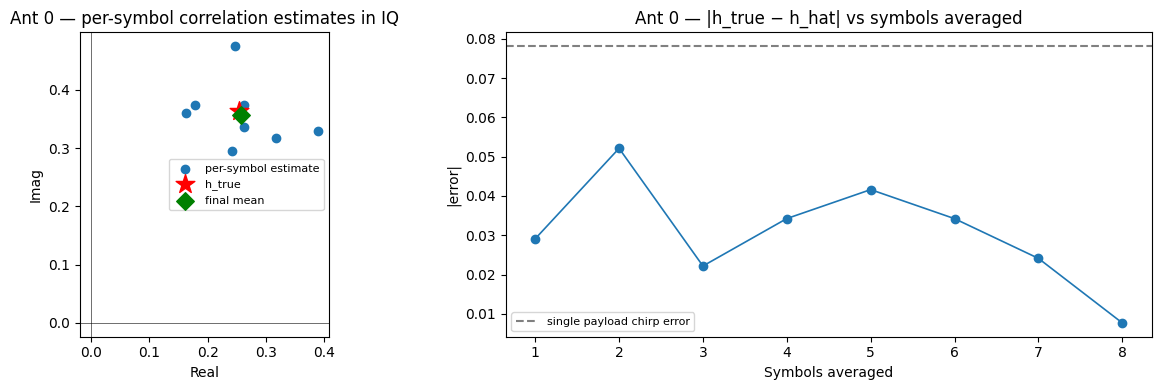

Estimated N0: 1.9825  (true N0: 3.1623)

Ant                h_true         h_hat (8 sym)  |err| 8sym  |err| 1sym
----------------------------------------------------------------------
  0        0.2541+0.3646j        0.2577+0.3578j      0.0077      0.0781
  1       -0.7045-0.2241j       -0.7052-0.2431j      0.0190      0.0423
  2       -0.1691-0.1208j       -0.1580-0.1042j      0.0200      0.0209
  3        0.2418+0.8255j        0.2490+0.8488j      0.0244      0.0925


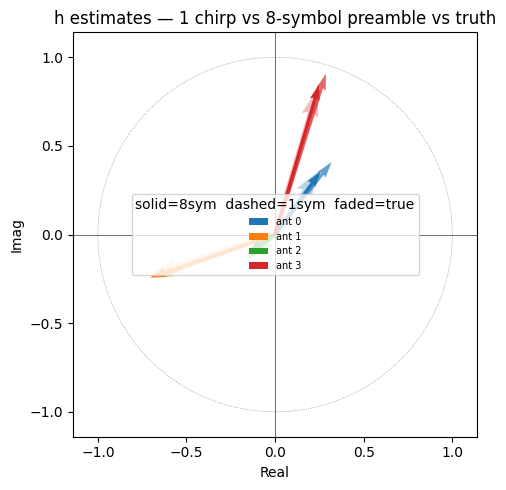

In [187]:
ref_chirp   = upchirp(M)
preamble_tx = np.tile(ref_chirp, N_PREAMBLE)  # (N_PREAMBLE * M,)

rx_preamble = np.stack([
    apply_channel(preamble_tx, h_true[j], N0)
    for j in range(NR)
])  # (NR, N_PREAMBLE * M)

# --- Step 1: per-symbol correlation output for antenna 0 ---
# Correlating each upchirp segment against ref gives a noisy estimate of h
c_conj = np.conj(ref_chirp)
per_sym = np.array([
    np.dot(rx_preamble[0, k*M:(k+1)*M], c_conj) / M
    for k in range(N_PREAMBLE)
])  # complex h estimate from each symbol independently

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(per_sym.real, per_sym.imag, zorder=3, label='per-symbol estimate')
axes[0].scatter(h_true[0].real, h_true[0].imag, marker='*', s=200, color='red', zorder=4, label='h_true')
running_mean = np.cumsum(per_sym) / np.arange(1, N_PREAMBLE + 1)
axes[0].scatter(running_mean[-1].real, running_mean[-1].imag, marker='D', s=80, color='green', zorder=4, label='final mean')
axes[0].axhline(0, color='k', lw=0.4); axes[0].axvline(0, color='k', lw=0.4)
axes[0].set_aspect('equal')
axes[0].legend(fontsize=8)
axes[0].set_title('Ant 0 — per-symbol correlation estimates in IQ')
axes[0].set_xlabel('Real'); axes[0].set_ylabel('Imag')

# convergence of |error| as we average more symbols
err_vs_sym = np.abs(running_mean - h_true[0])
axes[1].plot(range(1, N_PREAMBLE + 1), err_vs_sym, 'o-', lw=1.2)
axes[1].axhline(abs(h_hat_single[0] - h_true[0]), color='grey', linestyle='--', label='single payload chirp error')
axes[1].set_title('Ant 0 — |h_true − h_hat| vs symbols averaged')
axes[1].set_xlabel('Symbols averaged')
axes[1].set_ylabel('|error|')
axes[1].set_xticks(range(1, N_PREAMBLE + 1))
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- Step 2: run full correlator bank over all antennas ---
cb    = CorrelatorBank(M=M, N_sym=N_PREAMBLE)
h_hat, N0_est = cb.correlate(rx_preamble, ref_chirp)

print(f'Estimated N0: {N0_est:.4f}  (true N0: {N0:.4f})\n')
print(f'{"Ant":>3}  {"h_true":>20}  {"h_hat (8 sym)":>20}  {"|err| 8sym":>10}  {"|err| 1sym":>10}')
print('-' * 70)
for j in range(NR):
    e8 = abs(h_hat[j]       - h_true[j])
    e1 = abs(h_hat_single[j] - h_true[j])
    print(f'  {j}  {h_true[j]:>20.4f}  {h_hat[j]:>20.4f}  {e8:>10.4f}  {e1:>10.4f}')

# --- Step 3: quiver plot — single chirp vs 8-symbol vs true ---
fig, ax = plt.subplots(figsize=(5, 5))
for j in range(NR):
    ax.quiver(0, 0, h_true[j].real,      h_true[j].imag,
              angles='xy', scale_units='xy', scale=1,
              color=f'C{j}', alpha=0.3, width=0.014)
    ax.quiver(0, 0, h_hat_single[j].real, h_hat_single[j].imag,
              angles='xy', scale_units='xy', scale=1,
              color=f'C{j}', alpha=0.7, width=0.008, linestyle='dashed')
    ax.quiver(0, 0, h_hat[j].real,        h_hat[j].imag,
              angles='xy', scale_units='xy', scale=1,
              color=f'C{j}', width=0.008,
              label=f'ant {j}')

lim = max(np.abs(np.concatenate([h_true, h_hat, h_hat_single])).max() * 1.2, 0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.add_patch(plt.Circle((0,0), 1, color='grey', fill=False, lw=0.5, linestyle=':'))
ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
ax.set_aspect('equal')
ax.legend(fontsize=7, title='solid=8sym  dashed=1sym  faded=true')
ax.set_title('h estimates — 1 chirp vs 8-symbol preamble vs truth')
ax.set_xlabel('Real'); ax.set_ylabel('Imag')
plt.tight_layout()
plt.show()

### Correlator sensitivity to carrier frequency offset

A carrier offset Δf multiplies every received sample by exp(j·2π·Δf·n/Fs).
When the correlator computes s\*[n]·r[n], the chirp terms cancel exactly, leaving a
pure geometric sum:

$$\hat{h}(\Delta f) = h \cdot \underbrace{\frac{\sin(\pi \Delta f M / F_s)}{M \sin(\pi \Delta f / F_s)}}_{\text{per-symbol sinc}} \cdot \underbrace{\frac{\sin(\pi \Delta f N M / F_s)}{N \sin(\pi \Delta f M / F_s)}}_{\text{inter-symbol sinc}}$$

First nulls:
- **1 symbol** : Δf = BW/M (≈ 244 Hz at SF9)
- **N-symbol complex average** : Δf = BW/(N·M) (≈ 30 Hz for N=8)

Magnitude combining (average |corr|, not corr) keeps the wider single-symbol lobe
at the cost of losing the coherent SNR boost.

/tmp/ipykernel_187618/1440140323.py:12: RuntimeWarning: invalid value encountered in divide
  np.abs(np.sin(arg)) / (K * np.abs(np.sin(darg))))


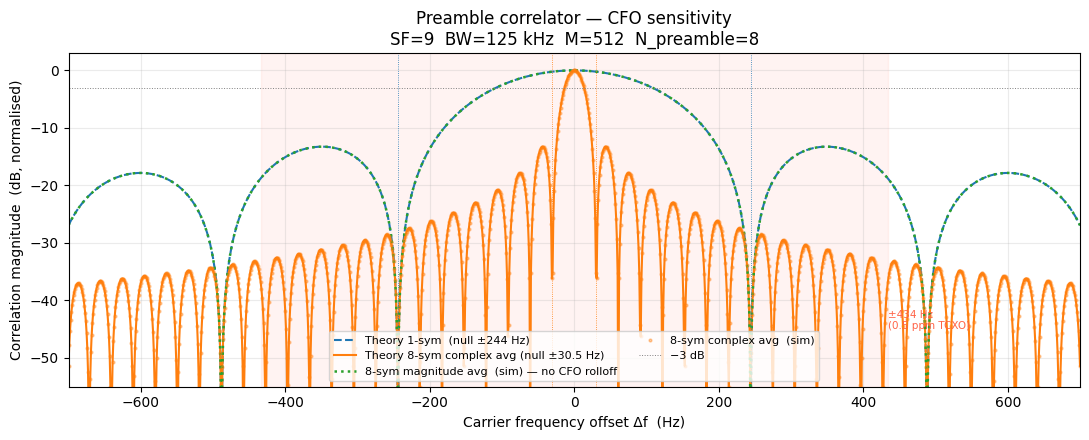

Single-symbol first null:  ±244.1 Hz  (= BW/M = 125e3/512)
8-symbol complex-avg null: ±30.5 Hz  (= BW/(N·M))
 0.5 ppm @ 868 MHz = 434 Hz → complex avg: -36.9 dB   mag avg: -18.8 dB
 1.0 ppm @ 868 MHz = 868 Hz → complex avg: -39.2 dB   mag avg: -21.1 dB
 2.0 ppm @ 868 MHz = 1736 Hz → complex avg: -54.1 dB   mag avg: -36.3 dB


In [188]:
# ── Correlator vs frequency offset ────────────────────────────────────────
df_max   = 700                               # sweep ±700 Hz
df_sweep = np.linspace(-df_max, df_max, 1401)
n_full   = np.arange(N_PREAMBLE * M)
ref_c    = np.conj(upchirp(M))

def dirichlet(df, K, fs=Fs):
    """Normalised Dirichlet-sinc magnitude for K samples at rate fs."""
    arg  = np.pi * df * K / fs
    darg = np.pi * df / fs
    return np.where(np.abs(darg) < 1e-12, 1.0,
                    np.abs(np.sin(arg)) / (K * np.abs(np.sin(darg))))

# Theoretical: single-symbol and N-symbol complex-coherent
env_1sym = dirichlet(df_sweep, M)
env_Nsym = dirichlet(df_sweep, N_PREAMBLE * M)

# Simulation (noiseless, single antenna)
h0       = h_true[0]
sim_coh  = []   # |mean(corr_k)|  — complex averaging
sim_mag  = []   # mean(|corr_k|)  — magnitude combining

for df in df_sweep:
    shift  = np.exp(1j * 2 * np.pi * df * n_full / Fs)
    rx     = preamble_tx * h0 * shift
    corrs  = np.array([np.dot(rx[k*M:(k+1)*M], ref_c) / M for k in range(N_PREAMBLE)])
    sim_coh.append(abs(np.mean(corrs))  / abs(h0))
    sim_mag.append(np.mean(np.abs(corrs)) / abs(h0))

sim_coh = np.array(sim_coh)
sim_mag = np.array(sim_mag)

null_1 = Fs / M
null_N = Fs / (N_PREAMBLE * M)

fig, ax = plt.subplots(figsize=(11, 4.5))

ax.plot(df_sweep, 20*np.log10(env_1sym + 1e-15),  'C0--', lw=1.5,
        label=f'Theory 1-sym  (null ±{null_1:.0f} Hz)')
ax.plot(df_sweep, 20*np.log10(env_Nsym + 1e-15),  'C1-',  lw=1.5,
        label=f'Theory {N_PREAMBLE}-sym complex avg (null ±{null_N:.1f} Hz)')
ax.plot(df_sweep, 20*np.log10(sim_mag  + 1e-15),  'C2:',  lw=1.8,
        label=f'{N_PREAMBLE}-sym magnitude avg  (sim) — no CFO rolloff')
ax.plot(df_sweep, 20*np.log10(sim_coh  + 1e-15),  'C1o',  ms=2, alpha=0.4,
        label=f'{N_PREAMBLE}-sym complex avg  (sim)')

ax.axhline(-3, color='grey', lw=0.7, linestyle=':', label='−3 dB')

# Null markers
for df_null, col in [(null_1, 'C0'), (null_N, 'C1')]:
    ax.axvline( df_null, color=col, lw=0.6, linestyle=':')
    ax.axvline(-df_null, color=col, lw=0.6, linestyle=':')

# Typical oscillator accuracy at 868 MHz
for ppm, ls, lbl in [(0.5, '--', '0.5 ppm TCXO'), (2, ':', '2 ppm XO')]:
    df_osc = ppm * 868e6 / 1e6
    if df_osc <= df_max:
        ax.axvspan(-df_osc, df_osc, alpha=0.07, color='tomato')
        ax.annotate(f'±{df_osc:.0f} Hz\n({lbl})',
                    xy=(df_osc, -45), fontsize=7.5, color='tomato', ha='left')

ax.set_xlim(-df_max, df_max)
ax.set_ylim(-55, 3)
ax.set_xlabel('Carrier frequency offset Δf  (Hz)')
ax.set_ylabel('Correlation magnitude  (dB, normalised)')
ax.set_title(f'Preamble correlator — CFO sensitivity\n'
             f'SF={SF}  BW={BW/1e3:.0f} kHz  M={M}  N_preamble={N_PREAMBLE}')
ax.legend(fontsize=8, loc='lower center', ncol=2)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print(f'Single-symbol first null:  ±{null_1:.1f} Hz  (= BW/M = {BW/1e3:.0f}e3/{M})')
print(f'{N_PREAMBLE}-symbol complex-avg null: ±{null_N:.1f} Hz  (= BW/(N·M))')
for ppm in [0.5, 1, 2]:
    df_osc = ppm * 868e6 / 1e6
    loss_coh = 20*np.log10(float(dirichlet(df_osc, N_PREAMBLE * M)) + 1e-15)
    loss_mag = 20*np.log10(float(dirichlet(df_osc, M)) + 1e-15)
    print(f'{ppm:4.1f} ppm @ 868 MHz = {df_osc:.0f} Hz → '
          f'complex avg: {loss_coh:+.1f} dB   mag avg: {loss_mag:+.1f} dB')


## Stage 5a/5c — Phase Extraction & Combining Weights
`compute_weights` runs in PicoRV32 firmware. Outputs are quantised to Q1.15.

Stage 5a — phase corrections φ (radians):
  ant 0: φ = +0.9467 rad  (+54.2°)
  ant 1: φ = -2.8096 rad  (-161.0°)
  ant 2: φ = -2.5589 rad  (-146.6°)
  ant 3: φ = +1.2854 rad  (+73.6°)

Stage 5c — real combining weights c:
  ant 0: c = 0.046417
  ant 1: c = 0.078522
  ant 2: c = 0.019928
  ant 3: c = 0.093109
  Sum of weights: 0.2380


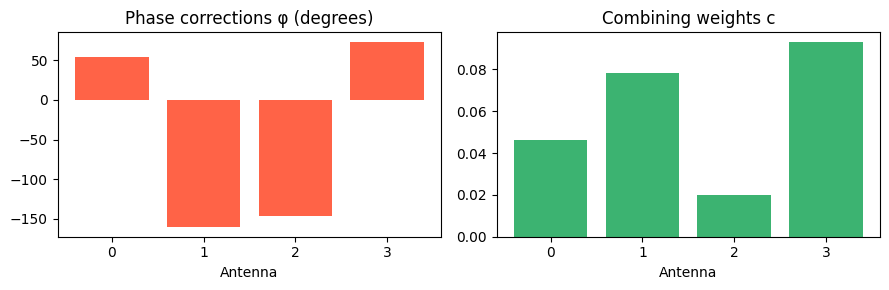

In [189]:
phi, c = compute_weights(h_hat, N0_est)

print('Stage 5a — phase corrections φ (radians):')
for j in range(NR):
    print(f'  ant {j}: φ = {phi[j]:+.4f} rad  ({np.degrees(phi[j]):+.1f}°)')

print('\nStage 5c — real combining weights c:')
for j in range(NR):
    print(f'  ant {j}: c = {c[j]:.6f}')
print(f'  Sum of weights: {np.sum(c):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].bar(range(NR), np.degrees(phi), color='tomato')
axes[0].set_title('Phase corrections φ (degrees)')
axes[0].set_xlabel('Antenna')
axes[0].set_xticks(range(NR))

axes[1].bar(range(NR), c, color='mediumseagreen')
axes[1].set_title('Combining weights c')
axes[1].set_xlabel('Antenna')
axes[1].set_xticks(range(NR))

plt.tight_layout()
plt.show()

## Stage 5b — Phase Correction
Multiply each antenna stream by `exp(-jφ)` to align phases before combining.

Peak bin phasors at b_tx=340:
  Ant  Before (°)   After (°)     Δ (°)
    0        +52.1        -2.2     -54.2°
    1       -160.1        +0.8    +161.0°
    2       -138.7        +7.9    +146.6°
    3        +72.4        -1.2     -73.6°


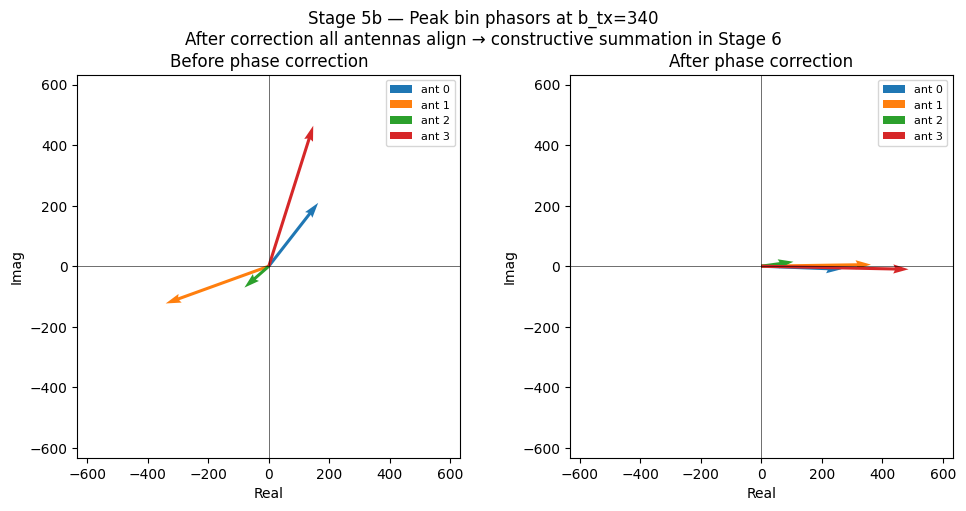

In [190]:
x_prime = rx_payload * np.exp(-1j * phi)[:, None]  # (NR, M)

n = np.arange(M)
def peak_phasor(sig):
    """Complex value of the dechirped FFT at the transmitted bin."""
    return np.fft.fft(sig * np.exp(-1j * np.pi * n**2 / M))[b_tx]

phasors_before = np.array([peak_phasor(rx_payload[j]) for j in range(NR)])
phasors_after  = np.array([peak_phasor(x_prime[j])    for j in range(NR)])

print(f'Peak bin phasors at b_tx={b_tx}:')
print(f'  {"Ant":>3}  {"Before (°)":>10}  {"After (°)":>10}  {"Δ (°)":>8}')
for j in range(NR):
    print(f'    {j}   {np.degrees(np.angle(phasors_before[j])):>+10.1f}'
          f'  {np.degrees(np.angle(phasors_after[j])):>+10.1f}'
          f'  {np.degrees(np.angle(phasors_after[j]) - np.angle(phasors_before[j])):>+8.1f}°')

# Phasor plot — before vs after in the complex plane
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, phasors, title in zip(axes,
                               [phasors_before, phasors_after],
                               ['Before phase correction', 'After phase correction']):
    for j in range(NR):
        p = phasors[j]
        ax.quiver(0, 0, p.real, p.imag,
                  angles='xy', scale_units='xy', scale=1,
                  color=f'C{j}', width=0.008, label=f'ant {j}')
    lim = np.abs(phasors).max() * 1.3
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlabel('Real'); ax.set_ylabel('Imag')
    ax.legend(fontsize=8)

plt.suptitle(f'Stage 5b — Peak bin phasors at b_tx={b_tx}\n'
             f'After correction all antennas align → constructive summation in Stage 6')
plt.tight_layout()
plt.show()

## Stage 6 — MRC Combining
Weighted sum of the four phase-corrected streams → single combined signal.

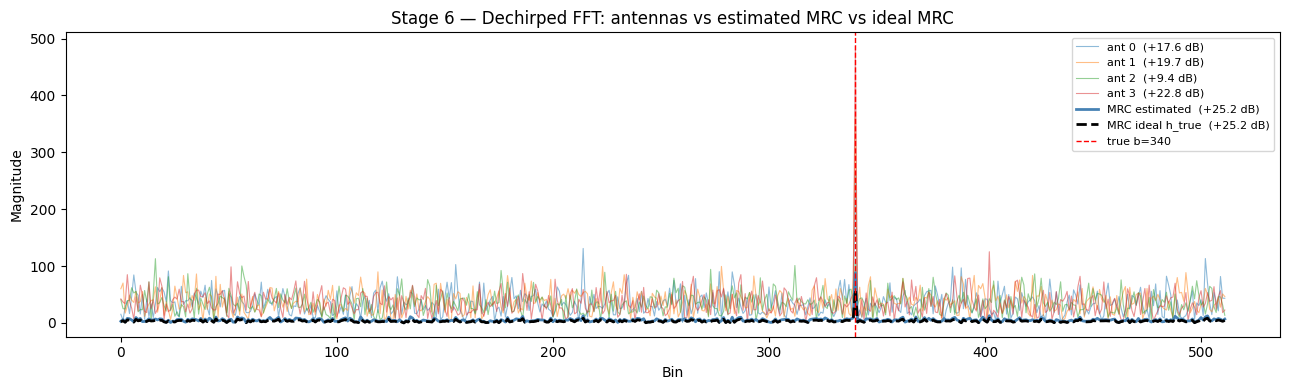

                       SNR proxy
----------------------------------
  ant 0 (|h|=0.444)        +17.6 dB
  ant 1 (|h|=0.739)        +19.7 dB
  ant 2 (|h|=0.208)         +9.4 dB
  ant 3 (|h|=0.860)        +22.8 dB
  Best single antenna        +22.8 dB
  MRC (h_hat)                +25.2 dB   ✓ better
  MRC (h_true)               +25.2 dB   ✓ always ≥ best antenna (theoretical guarantee)

  Estimation loss: -0.0 dB  (cost of using h_hat vs h_true)


In [191]:
y_mrc = mrc_combine(rx_payload, phi, c)  # estimated MRC (uses h_hat)

# Ideal MRC using true channel coefficients (lower bound on estimation loss)
phi_true, c_true = compute_weights(h_true, N0)
y_mrc_ideal = mrc_combine(rx_payload, phi_true, c_true)

n = np.arange(M)
def dechirp(sig):
    return np.fft.fft(sig * np.exp(-1j * np.pi * n**2 / M))

def snr_proxy(fft_out):
    mag = np.abs(fft_out)
    peak = mag[b_tx]
    noise = np.delete(mag, b_tx).mean()
    return 20 * np.log10(peak / (noise + 1e-12))

fft_mrc_est  = dechirp(y_mrc)
fft_mrc_ideal = dechirp(y_mrc_ideal)
fft_ants = [dechirp(rx_payload[j]) for j in range(NR)]
snr_ants = np.array([snr_proxy(f) for f in fft_ants])

# --- FFT overlay ---
fig, ax = plt.subplots(figsize=(13, 4))
for j in range(NR):
    ax.plot(np.abs(fft_ants[j]), lw=0.8, alpha=0.5,
            label=f'ant {j}  ({snr_ants[j]:+.1f} dB)')
ax.plot(np.abs(fft_mrc_est),  lw=2, color='steelblue',
        label=f'MRC estimated  ({snr_proxy(fft_mrc_est):+.1f} dB)')
ax.plot(np.abs(fft_mrc_ideal), lw=2, color='black', linestyle='--',
        label=f'MRC ideal h_true  ({snr_proxy(fft_mrc_ideal):+.1f} dB)')
ax.axvline(b_tx, color='red', lw=1, linestyle='--', label=f'true b={b_tx}')
ax.set_title('Stage 6 — Dechirped FFT: antennas vs estimated MRC vs ideal MRC')
ax.set_xlabel('Bin'); ax.set_ylabel('Magnitude')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- Summary table ---
snr_est   = snr_proxy(fft_mrc_est)
snr_ideal = snr_proxy(fft_mrc_ideal)
snr_best  = snr_ants.max()

print(f'{"":>20}  {"SNR proxy":>10}')
print('-' * 34)
for j in range(NR):
    print(f'  ant {j} (|h|={abs(h_true[j]):.3f})   {snr_ants[j]:>+10.1f} dB')
print(f'  Best single antenna   {snr_best:>+10.1f} dB')
print(f'  MRC (h_hat)           {snr_est:>+10.1f} dB   {"✓ better" if snr_est > snr_best else "✗ worse — estimation error"}')
print(f'  MRC (h_true)          {snr_ideal:>+10.1f} dB   {"✓ always ≥ best antenna (theoretical guarantee)"}')
print(f'\n  Estimation loss: {snr_ideal - snr_est:.1f} dB  (cost of using h_hat vs h_true)')

b_seq = [30, 402, 324, 282, 407, 124]


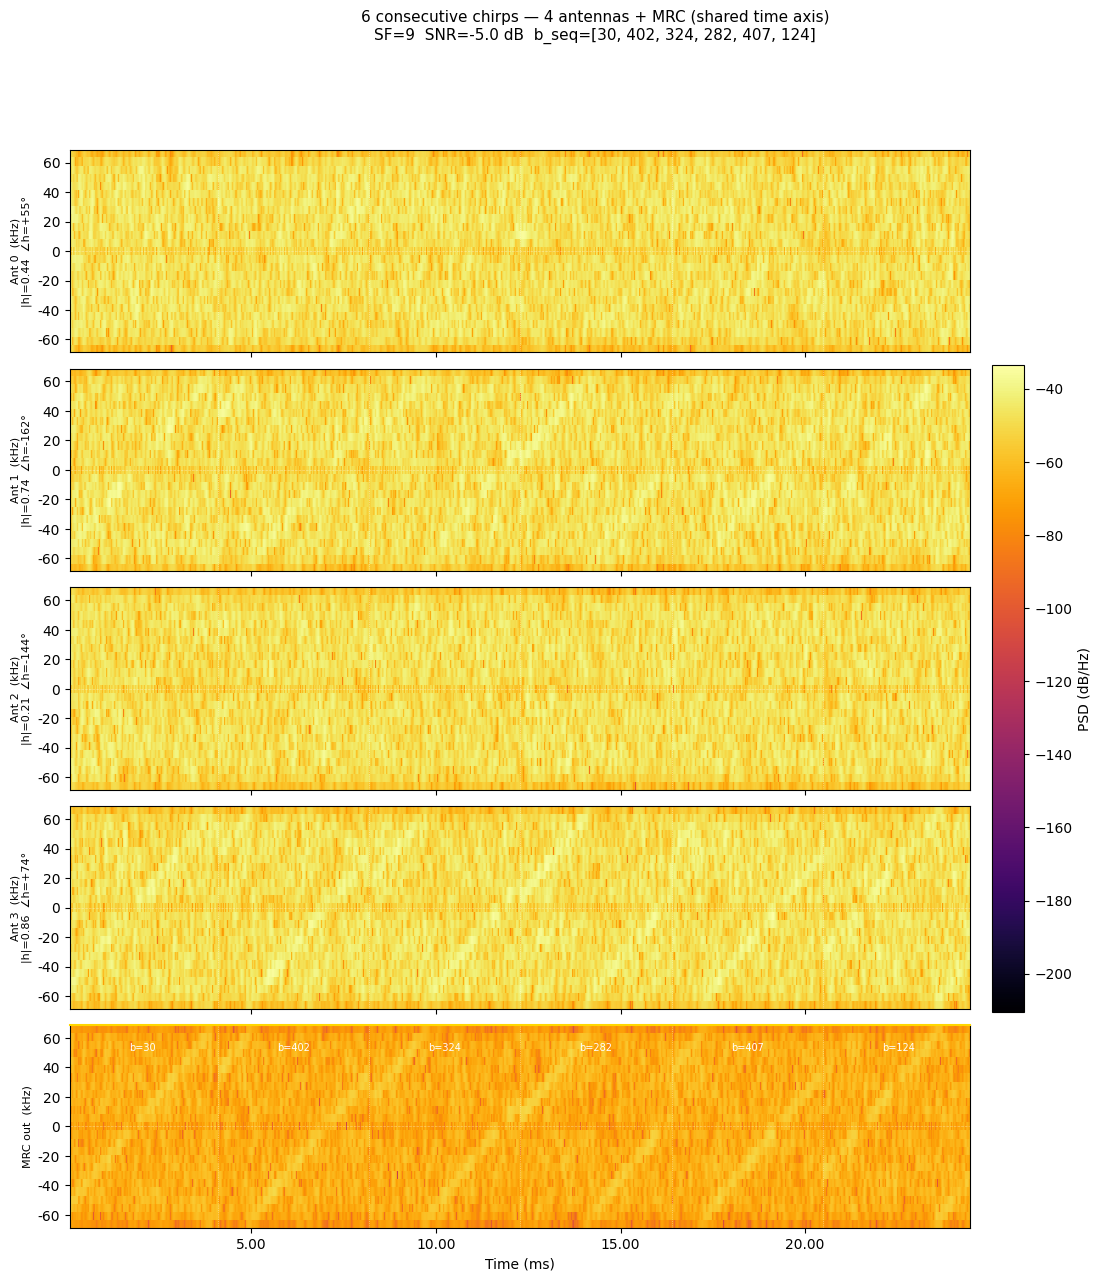

In [192]:

# ── Multi-chirp spectrogram: 6 symbols — all signals stacked vertically ────
# Shared time axis makes per-antenna vs MRC comparison direct.

N_SYM_VIZ = 6
rng_viz    = np.random.default_rng(77)
b_seq      = [int(rng_viz.integers(0, M)) for _ in range(N_SYM_VIZ)]
s_multi    = np.concatenate([modulate(b, M) for b in b_seq])

rx_multi         = np.stack([apply_channel(s_multi, h_true[j], N0) for j in range(NR)])
rx_multi_aligned = rx_multi * np.exp(-1j * phi)[:, None]
y_multi_mrc      = np.sum(rx_multi_aligned * c[:, None], axis=0)

sym_boundaries = [k * M / Fs for k in range(1, N_SYM_VIZ)]

print(f'b_seq = {b_seq}')

# NR antennas + 1 MRC row, all sharing the same time axis
n_rows = NR + 1
fig, axes = plt.subplots(n_rows, 1, figsize=(14, 2.8 * n_rows),
                          sharex=True,
                          gridspec_kw=dict(hspace=0.08))

fig.suptitle(
    f'{N_SYM_VIZ} consecutive chirps — 4 antennas + MRC (shared time axis)\n'
    f'SF={SF}  SNR={SNR_DB} dB  b_seq={b_seq}',
    fontsize=11
)

all_ims = []

# Rows 0..NR-1 — per-antenna spectrograms
for j in range(NR):
    ax = axes[j]
    im = plot_specgram(ax, rx_multi[j], fs=Fs)
    for t in sym_boundaries:
        ax.axvline(t, color='white', lw=0.6, linestyle=':', alpha=0.5)
    h = h_true[j]
    ax.set_ylabel(f'Ant {j}  (kHz)\n|h|={abs(h):.2f}  ∠h={np.degrees(np.angle(h)):+.0f}°', fontsize=8)
    ax.set_xlabel('')   # suppress — sharex shows ticks only on bottom
    all_ims.append(im)

# Row NR — MRC combined output; draw a subtle top border to mark the boundary
ax_mrc = axes[NR]
ax_mrc.spines['top'].set(linewidth=1.5, color='gold')
im_mrc = plot_specgram(ax_mrc, y_multi_mrc, fs=Fs)
for k, t in enumerate(sym_boundaries):
    ax_mrc.axvline(t, color='white', lw=0.6, linestyle=':', alpha=0.5)
    ax_mrc.text((k + 0.5) * M / Fs, Fs / 2 * 0.82,
                f'b={b_seq[k]}', color='white', fontsize=7, ha='center')
ax_mrc.text((N_SYM_VIZ - 0.5) * M / Fs, Fs / 2 * 0.82,
            f'b={b_seq[-1]}', color='white', fontsize=7, ha='center')
ax_mrc.set_ylabel('MRC out  (kHz)', fontsize=8)
all_ims.append(im_mrc)

# Shared colour scale across all rows
clims  = [im.get_clim() for im in all_ims]
vmin_s = min(cl[0] for cl in clims)
vmax_s = max(cl[1] for cl in clims)
for im in all_ims:
    im.set_clim(vmin_s, vmax_s)

fig.colorbar(im_mrc, ax=axes.tolist(), label='PSD (dB/Hz)', shrink=0.6, pad=0.02)
plt.show()


### SNR proxy — limitations

The `snr_proxy` function estimates SNR from a single dechirped FFT as:

$$\widehat{\text{SNR}} = 20 \log_{10} \frac{|Z[b_{\text{tx}}]|}{\overline{|Z[k \neq b_{\text{tx}}]|}}$$

This is a useful sanity check but has several known limitations:

1. **Few noise bins → high variance.** At SF7 the FFT has only $M = 128$ bins, leaving 127 bins to estimate the noise floor. The sample mean of 127 Rayleigh-distributed magnitudes has a coefficient of variation $\approx 1/\sqrt{127} \approx 9\%$, so the single-packet estimate fluctuates by several dB — especially at low SNR where the signal peak is itself noisy.

2. **Rayleigh fading randomises the signal peak.** Each packet draws a fresh Rayleigh channel coefficient. $|h_j|$ itself is $\chi$-distributed, so $|Z[b_{\text{tx}}]|$ varies packet-to-packet independently of noise. A single-packet reading conflates fading amplitude with noise.

3. **Dechirped-domain SNR ≠ input SNR.** The proxy measures post-dechirp, post-combining SNR. This differs from the per-antenna input SNR (`N0`) by the combining gain, the channel amplitude, and any fixed-point quantisation loss — they are correlated but not interchangeable.

4. **Not a BER predictor.** The proxy uses peak magnitude, not the demodulation decision distance. A high proxy SNR does not guarantee correct symbol detection (phase errors, ISI from fading within a long packet).

**Consequence:** The single-packet cell above is for visual intuition only. The 300-trial averaging cell below is required to compare combining strategies reliably. For rigorous BER characterisation, use the Monte Carlo sweep in the BER check cell.

Mean SNR proxy over 300 packets at SNR=-5.0 dB:

                      Mean SNR   vs best ant
--------------------------------------------
  ant 0                  +21.0 dB
  ant 1                  +20.9 dB
  ant 2                  +20.3 dB
  ant 3                  +20.5 dB
      best antenna       +21.0 dB
       MRC (h_hat)       +28.7 dB    +7.7 dB ✓
      MRC (h_true)       +28.7 dB    +7.7 dB ✓


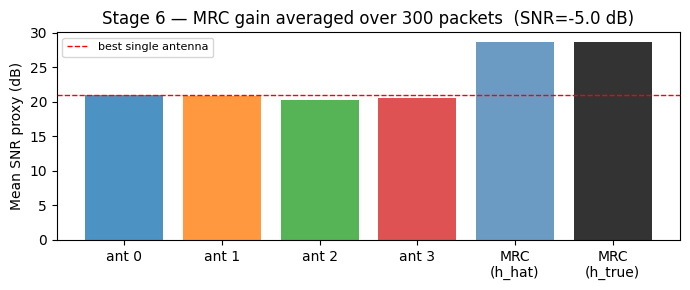

In [193]:
# Single-packet SNR proxy has high variance at low SNR (noise floor from only M-1=127 bins).
# Average over N_TRIALS packets to get a stable estimate.
N_TRIALS = 300
n_vec = np.arange(M)

snr_trials = {j: [] for j in range(NR)}
snr_trials['est']   = []
snr_trials['ideal'] = []

for _ in range(N_TRIALS):
    b_i  = int(rng.integers(0, M))
    s_i  = modulate(b_i, M)
    h_i  = rayleigh_coefficients(NR)
    rx_i = np.stack([apply_channel(s_i, h_i[j], N0) for j in range(NR)])

    rx_pre_i = np.stack([apply_channel(np.tile(upchirp(M), N_PREAMBLE), h_i[j], N0)
                          for j in range(NR)])
    h_hat_i, N0_i = cb.correlate(rx_pre_i, upchirp(M))

    phi_e_i, c_e_i = compute_weights(h_hat_i, N0_i)
    phi_t_i, c_t_i = compute_weights(h_i, N0)

    def _dechirp(sig):
        return np.fft.fft(sig * np.exp(-1j * np.pi * n_vec**2 / M))

    def _snr(sig):
        mag = np.abs(_dechirp(sig))
        return 20 * np.log10(mag[b_i] / (np.delete(mag, b_i).mean() + 1e-12))

    for j in range(NR):
        snr_trials[j].append(_snr(rx_i[j]))
    snr_trials['est'].append(_snr(mrc_combine(rx_i, phi_e_i, c_e_i)))
    snr_trials['ideal'].append(_snr(mrc_combine(rx_i, phi_t_i, c_t_i)))

snr_mean = {k: np.mean(v) for k, v in snr_trials.items()}
snr_best  = max(snr_mean[j] for j in range(NR))

print(f'Mean SNR proxy over {N_TRIALS} packets at SNR={SNR_DB} dB:\n')
print(f'  {"":>16}  {"Mean SNR":>10}  {"vs best ant":>12}')
print('-' * 44)
for j in range(NR):
    print(f'  ant {j:<12}  {snr_mean[j]:>+10.1f} dB')
print(f'  {"best antenna":>16}  {snr_best:>+10.1f} dB')
print(f'  {"MRC (h_hat)":>16}  {snr_mean["est"]:>+10.1f} dB  '
      f'  {snr_mean["est"]-snr_best:>+.1f} dB {"✓" if snr_mean["est"] > snr_best else "✗"}')
print(f'  {"MRC (h_true)":>16}  {snr_mean["ideal"]:>+10.1f} dB  '
      f'  {snr_mean["ideal"]-snr_best:>+.1f} dB {"✓" if snr_mean["ideal"] > snr_best else "✗"}')

fig, ax = plt.subplots(figsize=(7, 3))
labels = [f'ant {j}' for j in range(NR)] + ['MRC\n(h_hat)', 'MRC\n(h_true)']
values = [snr_mean[j] for j in range(NR)] + [snr_mean['est'], snr_mean['ideal']]
colours = [f'C{j}' for j in range(NR)] + ['steelblue', 'black']
bars = ax.bar(labels, values, color=colours, alpha=0.8)
ax.axhline(snr_best, color='red', lw=1, linestyle='--', label='best single antenna')
ax.set_ylabel('Mean SNR proxy (dB)')
ax.set_title(f'Stage 6 — MRC gain averaged over {N_TRIALS} packets  (SNR={SNR_DB} dB)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Stage 8 — ΣΔ Re-modulator

Converts the combined int16 IQ stream back to a 1-bit bitstream at 32 MS/s before feeding the SX1302 radio input.

**Architecture:** MASH 1-1-1 — three cascaded 1st-order stages, each unconditionally stable.
The quantisation noise cancels between stages, leaving NTF = $(1-z^{-1})^3$:
noise is high-pass shaped at **60 dB per decade** of frequency, so in-band SQNR grows at **70 dB per decade** of OSR.

| BW | OSR | Theoretical peak SQNR |
| --- | --- | --- |
| 1000 kHz | 32× | ≈ 85 dB |
| 500 kHz | 64× | ≈ 106 dB |
| 250 kHz | 128× | ≈ 127 dB |
| 125 kHz | 256× | ≈ 148 dB |

> **Simulation note:** the Python model uses causal 1st-order output (q₁) for the BER chain — sufficient since any OSR ≥ 16 gives > 40 dB SQNR, fully transparent for LoRa. The 3rd-order combined output Y = q₁ + Δq₂ + Δ²q₃ is used for the SQNR PSD demo.


Dechirped peak at b_tx=340:
  Before remod: 99.109
  After  remod: 94.618  (95.5% preserved)

Note: waveform SQNR is limited (~17 dB) for a full-bandwidth chirp because the
signal occupies the full baseband Nyquist. Relevant metric for LoRa is the
dechirped FFT peak ratio, not SQNR.


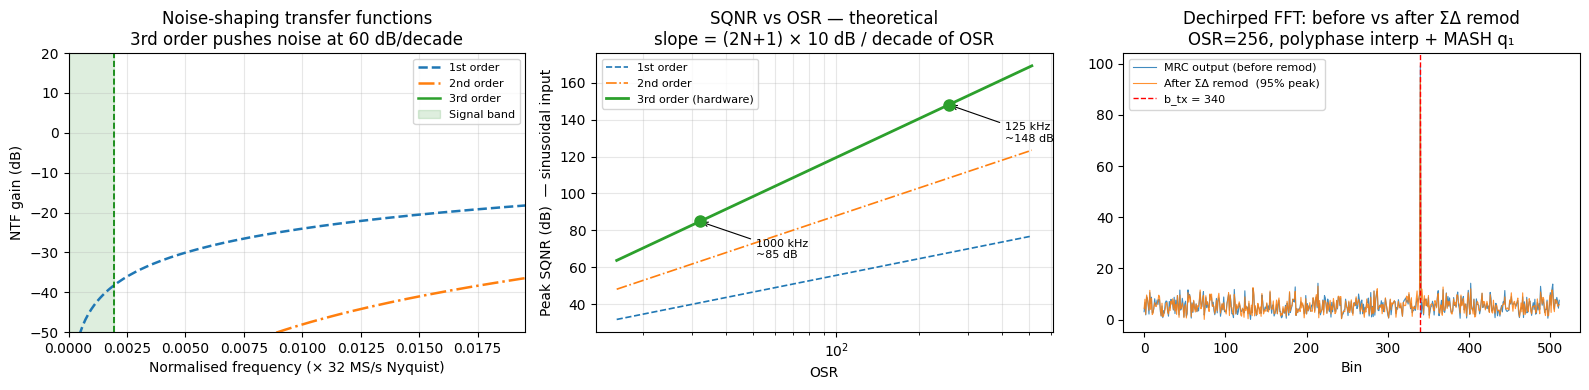

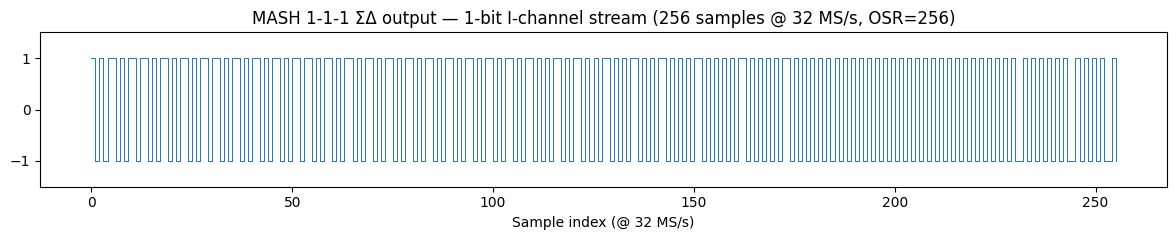

In [194]:
from scipy.signal import butter, sosfiltfilt, resample_poly

OSR = 256   # 125 kHz BW: 32 MS/s / 125 kS/s

# ── Normalise and upsample with polyphase interpolation ────────────────────
# Polyphase (not ZOH) matches the hardware DAC reconstruction filter:
# it avoids the large phase-discontinuity steps that occur in a LoRa chirp
# at the ZOH transition boundaries.
peak   = np.max(np.abs(y_mrc))
y_norm = y_mrc * (0.9 / peak)

y_up_re = resample_poly(y_norm.real, OSR, 1)[:M * OSR]
y_up_im = resample_poly(y_norm.imag, OSR, 1)[:M * OSR]
y_up    = y_up_re + 1j * y_up_im        # smooth 32 MS/s signal

# ── MASH ΣΔ → 1-bit stream ────────────────────────────────────────────────
remod  = SigmaDeltaRemodulator(order=3)
y_bits = remod.process_block(y_up)       # q₁ output (1-bit) @ 32 MS/s

# ── Reconstruct: LPF at baseband Nyquist + decimate ───────────────────────
sos_chain = butter(8, 1.0 / OSR, output='sos')
y_out_up  = sosfiltfilt(sos_chain, y_bits.real) + 1j * sosfiltfilt(sos_chain, y_bits.imag)
y_out     = y_out_up[::OSR][:M]         # back to baseband rate

# ── BER loop uses baseband ΣΔ (fast: no upsampling; Wn=0.9 for full chirp BW) ──
sos_ber   = butter(4, 0.9, output='sos')

# ── Dechirped FFT quality metric ──────────────────────────────────────────
n_arr = np.arange(M)
def dechirp(sig): return np.abs(np.fft.fft(sig * np.exp(-1j * np.pi * n_arr**2 / M)))
peak_before = dechirp(y_norm)[b_tx]
peak_after  = dechirp(y_out)[b_tx]
print(f'Dechirped peak at b_tx={b_tx}:')
print(f'  Before remod: {peak_before:.3f}')
print(f'  After  remod: {peak_after:.3f}  ({100*peak_after/peak_before:.1f}% preserved)')
print()
print('Note: waveform SQNR is limited (~17 dB) for a full-bandwidth chirp because the')
print('signal occupies the full baseband Nyquist. Relevant metric for LoRa is the')
print('dechirped FFT peak ratio, not SQNR.')

# ── Theoretical NTF shapes ─────────────────────────────────────────────────
f_arr    = np.linspace(1e-4, 0.5, 4000)
ntf_db   = {N: 10 * np.log10((2 * np.sin(np.pi * f_arr))**(2*N) + 1e-30)
             for N in [1, 2, 3]}

# ── Theoretical peak SQNR vs OSR (sinusoidal input, A = 0.9) ──────────────
osr_arr = np.logspace(np.log10(16), np.log10(512), 300)
A       = 0.9
def sqnr_th(N_ord, osr):
    return (10 * np.log10(3 * (2*N_ord + 1) / (2 * np.pi**(2*N_ord)))
            + (2*N_ord + 1) * 10 * np.log10(osr)
            + 20 * np.log10(A))

# ── Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1 — NTF shapes
sig_bw = 0.5 / OSR   # signal band upper edge (normalised to 32 MS/s Nyquist)
for N_ord, ls, col in [(1, '--', 'C0'), (2, '-.', 'C1'), (3, '-', 'C2')]:
    label = f'{N_ord}{"st" if N_ord==1 else "nd" if N_ord==2 else "rd"} order'
    axes[0].plot(f_arr, ntf_db[N_ord], ls=ls, color=col, lw=1.8, label=label)
axes[0].axvspan(0, sig_bw, alpha=0.13, color='green', label='Signal band')
axes[0].axvline(sig_bw, color='green', lw=1.2, ls='--')
axes[0].set_xlim(0, min(0.12, 10 * sig_bw))
axes[0].set_ylim(-50, 20)
axes[0].set_xlabel('Normalised frequency (× 32 MS/s Nyquist)')
axes[0].set_ylabel('NTF gain (dB)')
axes[0].set_title('Noise-shaping transfer functions\n3rd order pushes noise at 60 dB/decade')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# 2 — SQNR vs OSR (theoretical)
for N_ord, col, ls in [(1, 'C0', '--'), (2, 'C1', '-.'), (3, 'C2', '-')]:
    label = f'{N_ord}{"st" if N_ord==1 else "nd" if N_ord==2 else "rd"} order'
    if N_ord == 3: label += ' (hardware)'
    axes[1].plot(osr_arr, sqnr_th(N_ord, osr_arr), color=col, ls=ls,
                 lw=2 if N_ord==3 else 1.2, label=label)
for osr_op, bw_label in [(32, '1000 kHz\n~85 dB'), (256, '125 kHz\n~148 dB')]:
    sq = sqnr_th(3, osr_op)
    axes[1].plot(osr_op, sq, 'o', color='C2', markersize=8, zorder=5)
    axes[1].annotate(bw_label, xy=(osr_op, sq),
                     xytext=(osr_op * 1.6, sq - 20), fontsize=8,
                     arrowprops=dict(arrowstyle='->', lw=0.8))
axes[1].set_xscale('log')
axes[1].set_xlabel('OSR')
axes[1].set_ylabel('Peak SQNR (dB)  — sinusoidal input')
axes[1].set_title('SQNR vs OSR — theoretical\nslope = (2N+1) × 10 dB / decade of OSR')
axes[1].legend(fontsize=8)
axes[1].grid(True, which='both', alpha=0.3)

# 3 — Dechirped FFT before / after
axes[2].plot(dechirp(y_norm), lw=0.8, alpha=0.85, label='MRC output (before remod)')
axes[2].plot(dechirp(y_out),  lw=0.8, alpha=0.85, label=f'After ΣΔ remod  ({100*peak_after/peak_before:.0f}% peak)')
axes[2].axvline(b_tx, color='red', lw=1, ls='--', label=f'b_tx = {b_tx}')
axes[2].set_title(f'Dechirped FFT: before vs after ΣΔ remod\nOSR={OSR}, polyphase interp + MASH q₁')
axes[2].set_xlabel('Bin')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Bitstream snippet ─────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(12, 2.5))
ax2.plot(y_bits.real[:256], drawstyle='steps-post', lw=0.7)
ax2.set_title(f'MASH 1-1-1 ΣΔ output — 1-bit I-channel stream (256 samples @ 32 MS/s, OSR={OSR})')
ax2.set_ylim(-1.5, 1.5); ax2.set_xlabel('Sample index (@ 32 MS/s)')
plt.tight_layout(); plt.show()


## Stage 9 — Demodulation

The SX1302 receives the 1-bit re-modulated stream from Stage 8 and performs its own
internal dechirp + FFT. In simulation `demodulate()` models that step directly on the
reconstructed baseband signal `y_out`.

### Dechirp + FFT algorithm

A LoRa symbol `b` is a cyclic frequency shift of the base upchirp:

```
s_b[n] = exp(j·π·(2·b·n + n²) / M),   n = 0 … M-1
```

Multiplying by the conjugate downchirp `exp(-j·π·n²/M)` collapses the chirp to a
pure tone at bin `b`:

```
dechirped[n] = y[n] · exp(-j·π·n²/M)
             = exp(j·2π·b·n/M) · (channel + noise terms)
```

Taking the FFT and finding the argmax recovers the transmitted symbol:

```
b̂ = argmax |FFT(dechirped)|
```

### Processing gain

The FFT coherently integrates M = 2^SF samples, giving a processing gain of
`10·log10(M)` dB (21 dB at SF7, 36 dB at SF12). This is why the ΣΔ re-modulator
only needs to preserve the dechirped peak — quantisation noise is spread across all
M bins and averages down by M in the FFT magnitude.

In [195]:
b_rx = demodulate(y_out)

bit_errors = bin(b_tx ^ b_rx).count('1')
print(f'b_tx = {b_tx:3d}  →  b_rx = {b_rx:3d}')
print(f'Bit errors: {bit_errors} / {SF}')
print('PASS ✓' if b_tx == b_rx else f'FAIL ✗  (XOR = {b_tx ^ b_rx:07b})')

b_tx = 340  →  b_rx = 340
Bit errors: 0 / 9
PASS ✓


## Quick BER check
Run N packets at the chosen SNR to sanity-check everything above.

In [196]:
N_PACKETS = 200
n_err = n_bits = 0

for _ in range(N_PACKETS):
    b_i   = int(rng.integers(0, M))
    s_i   = modulate(b_i, M)
    h_i   = rayleigh_coefficients(NR)
    rx_i  = np.stack([apply_channel(s_i, h_i[j], N0) for j in range(NR)])

    rx_pre = np.stack([apply_channel(np.tile(upchirp(M), N_PREAMBLE), h_i[j], N0)
                       for j in range(NR)])
    h_hat_i, N0_i = cb.correlate(rx_pre, upchirp(M))
    phi_i, c_i    = compute_weights(h_hat_i, N0_i)

    y_i      = mrc_combine(rx_i, phi_i, c_i)
    peak_i   = np.max(np.abs(y_i))
    y_norm_i = y_i * (0.9 / (peak_i + 1e-12))

    # Baseband ΣΔ (no upsampling — fast; chirp processing gain compensates for quantisation noise)
    rm_i    = SigmaDeltaRemodulator(order=3)
    bits_i  = rm_i.process_block(y_norm_i)
    y_out_i = sosfiltfilt(sos_ber, bits_i.real) + 1j * sosfiltfilt(sos_ber, bits_i.imag)

    b_out = demodulate(y_out_i)
    n_err  += bin(b_i ^ b_out).count('1')
    n_bits += SF

ber = n_err / n_bits
print(f'SNR = {SNR_DB} dB   BER = {ber:.4e}   ({n_err} bit errors / {n_bits} bits,  {N_PACKETS} packets)')


SNR = -5.0 dB   BER = 6.1111e-03   (11 bit errors / 1800 bits,  200 packets)
